# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test10 pipeline

Notebook equivalent of `tests/6_mceq/test10_pipeline.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `mceq` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `mceq` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree, missing optional dependencies, or unavailable external model data.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test10_pipeline"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "6_mceq" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\6_mceq\test10_pipeline.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `mceq` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\mceq\test10_pipeline


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Plot: `step1_density_profile()`

**What is checked:** Step1 density profile behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `step1_density_profile()`

This block generates or validates files in `OUTPUT_DIR`:

- `step1_density_profile_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running step1_density_profile() ...

[1] Computing mceq atmospheric density profile...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Saved plot: V:\output\test\mceq\test10_pipeline\step1_density_profile_figure_001.png


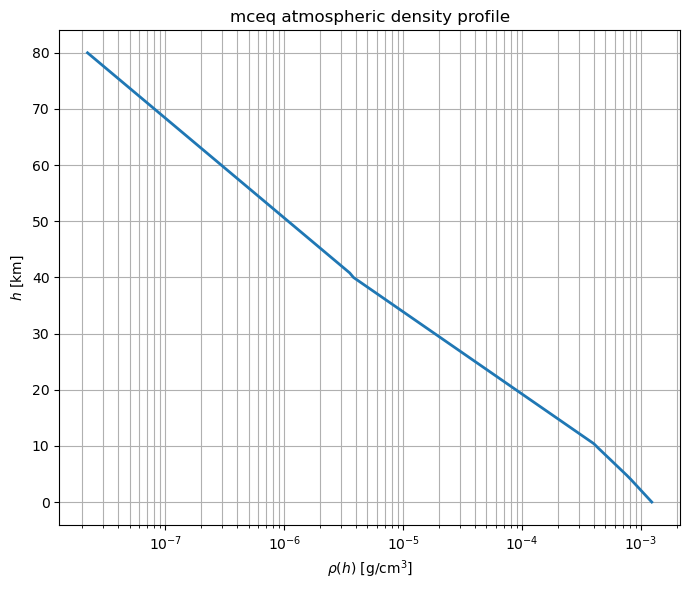

PASSED: step1_density_profile()


tensor([1.2298e-03, 1.1347e-03, 1.0470e-03, 9.6604e-04, 8.9135e-04, 8.2244e-04,
        7.5477e-04, 6.8905e-04, 6.2905e-04, 5.7428e-04, 5.2427e-04, 4.7862e-04,
        4.3695e-04, 4.0017e-04, 3.5288e-04, 3.1118e-04, 2.7441e-04, 2.4198e-04,
        2.1339e-04, 1.8817e-04, 1.6593e-04, 1.4633e-04, 1.2903e-04, 1.1379e-04,
        1.0034e-04, 8.8482e-05, 7.8026e-05, 6.8805e-05, 6.0675e-05, 5.3505e-05,
        4.7182e-05, 4.1606e-05, 3.6690e-05, 3.2354e-05, 2.8531e-05, 2.5159e-05,
        2.2186e-05, 1.9564e-05, 1.7252e-05, 1.5214e-05, 1.3416e-05, 1.1830e-05,
        1.0432e-05, 9.1996e-06, 8.1124e-06, 7.1538e-06, 6.3084e-06, 5.5629e-06,
        4.9056e-06, 4.3259e-06, 3.8147e-06, 3.5489e-06, 3.1996e-06, 2.8847e-06,
        2.6008e-06, 2.3449e-06, 2.1141e-06, 1.9060e-06, 1.7184e-06, 1.5493e-06,
        1.3968e-06, 1.2594e-06, 1.1354e-06, 1.0237e-06, 9.2292e-07, 8.3209e-07,
        7.5019e-07, 6.7636e-07, 6.0980e-07, 5.4978e-07, 4.9567e-07, 4.4689e-07,
        4.0291e-07, 3.6325e-07, 3.2750e-

In [4]:
run_notebook_call('step1_density_profile()', lambda: TEST_MODULE.step1_density_profile())


## Test: `test_pipeline_test0`

**What is checked:** Pipeline test0 behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


Running test_pipeline_test0 ...

PIPELINE TEST0: mceq atmospheric numu flux

[1] Computing mceq atmospheric density profile...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Saved plot: V:\output\test\mceq\test10_pipeline\test_pipeline_test0_figure_001.png


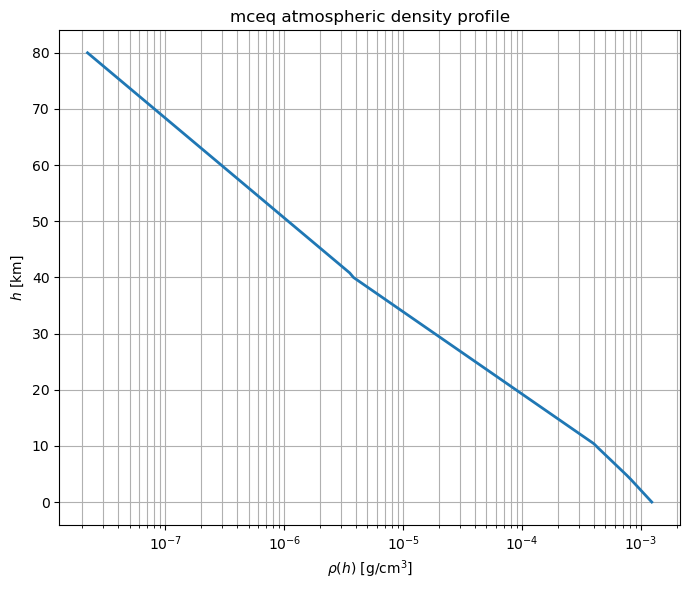


[2] Solving mceq for theta = 0 and 45 deg...

Solving theta = 0.0 deg
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to

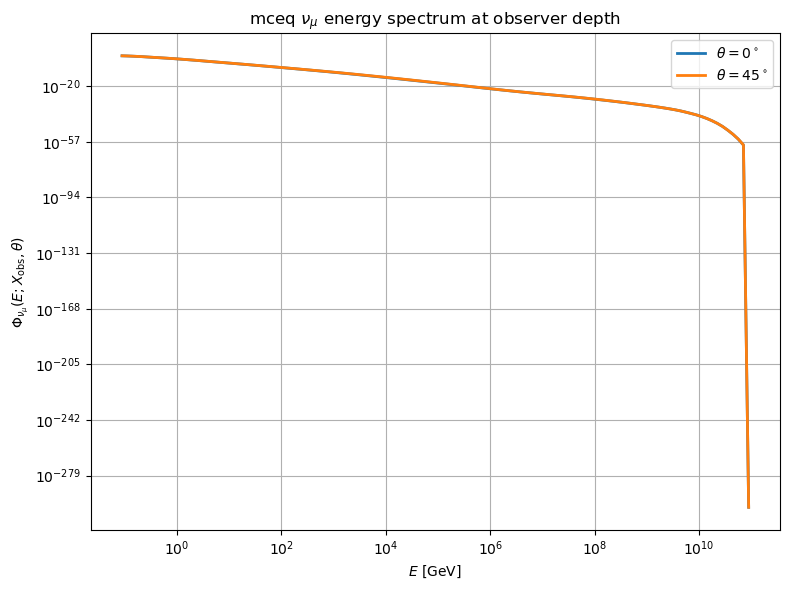


[3] Plotting mceq flux mapped onto h-grid...
Saved plot: V:\output\test\mceq\test10_pipeline\test_pipeline_test0_figure_003.png


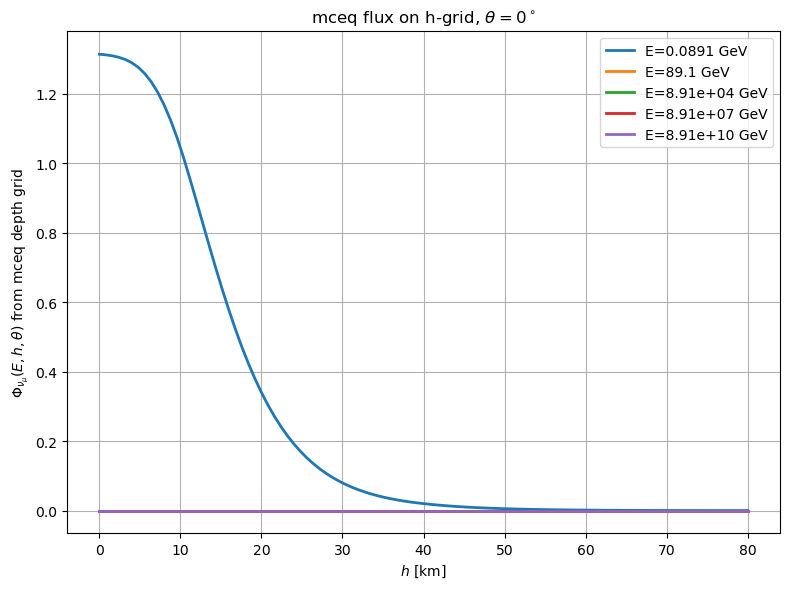

Saved plot: V:\output\test\mceq\test10_pipeline\test_pipeline_test0_figure_004.png


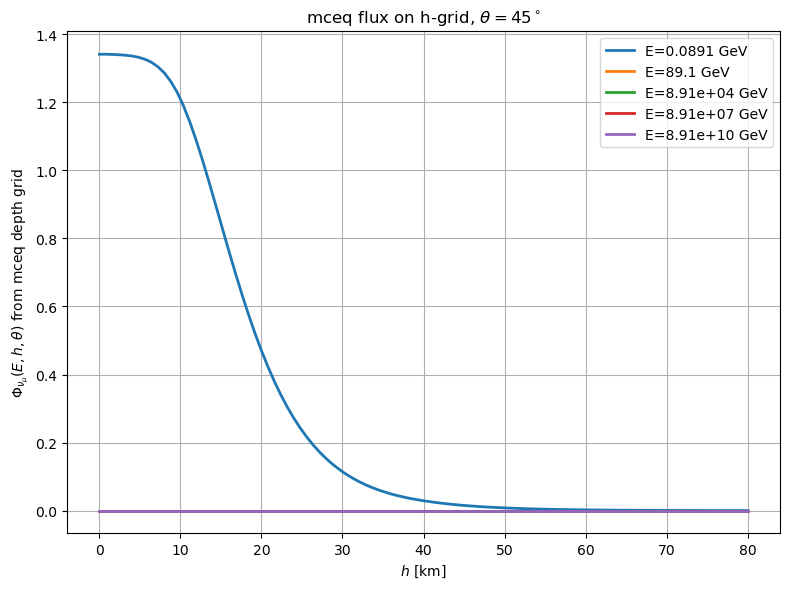


[4-5] Computing production profiles and Phi(E,h,theta)...

Computing production profile for theta = 0.0 deg
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set

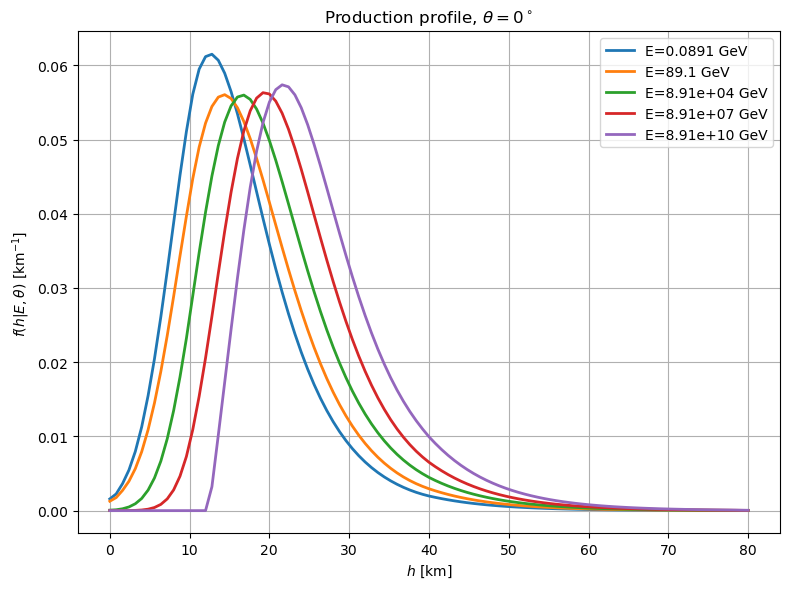

Saved plot: V:\output\test\mceq\test10_pipeline\test_pipeline_test0_figure_006.png


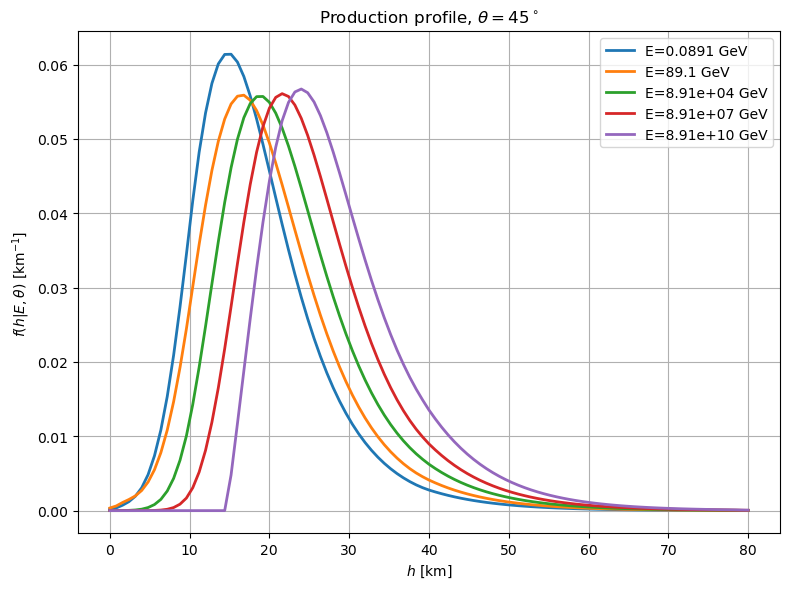


[5 plot] Plotting differential flux Phi(E,h,theta)...
Saved plot: V:\output\test\mceq\test10_pipeline\test_pipeline_test0_figure_007.png


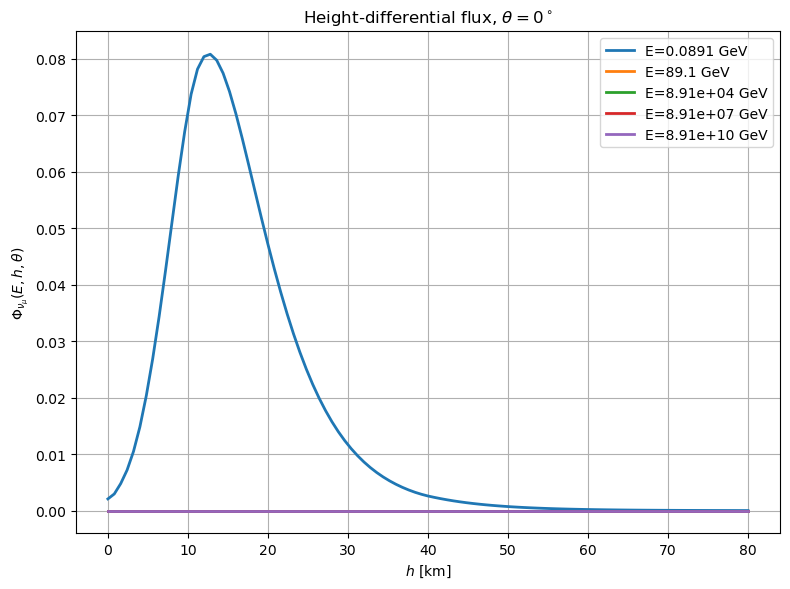

Saved plot: V:\output\test\mceq\test10_pipeline\test_pipeline_test0_figure_008.png


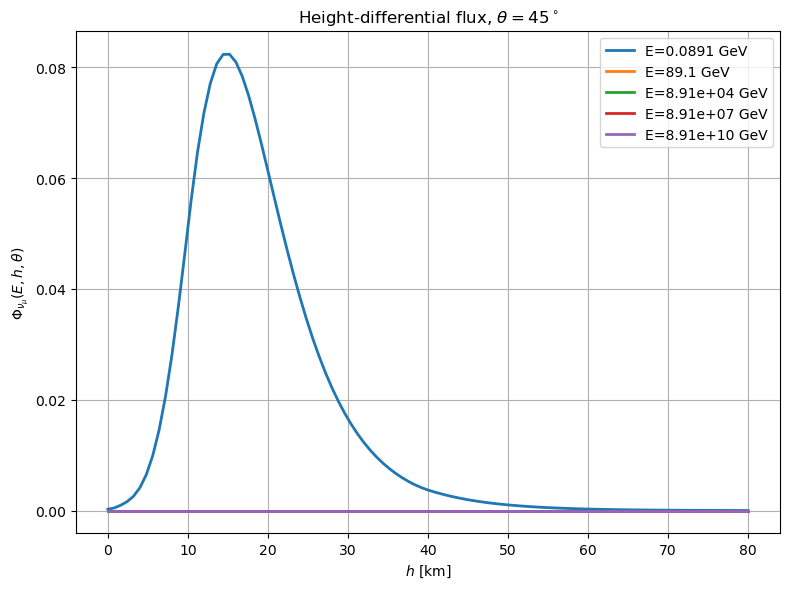


[6] Saving and reloading results...
Saved theta=0.0 deg -> V:\output\test\mceq\test10_pipeline\phi_E_theta_h_test0_numu_theta_0p000deg.pt
Saved theta=45.0 deg -> V:\output\test\mceq\test10_pipeline\phi_E_theta_h_test0_numu_theta_45p000deg.pt

[6 plot] Plotting loaded content in axes grid...
Saved plot: V:\output\test\mceq\test10_pipeline\test_pipeline_test0_figure_009.png


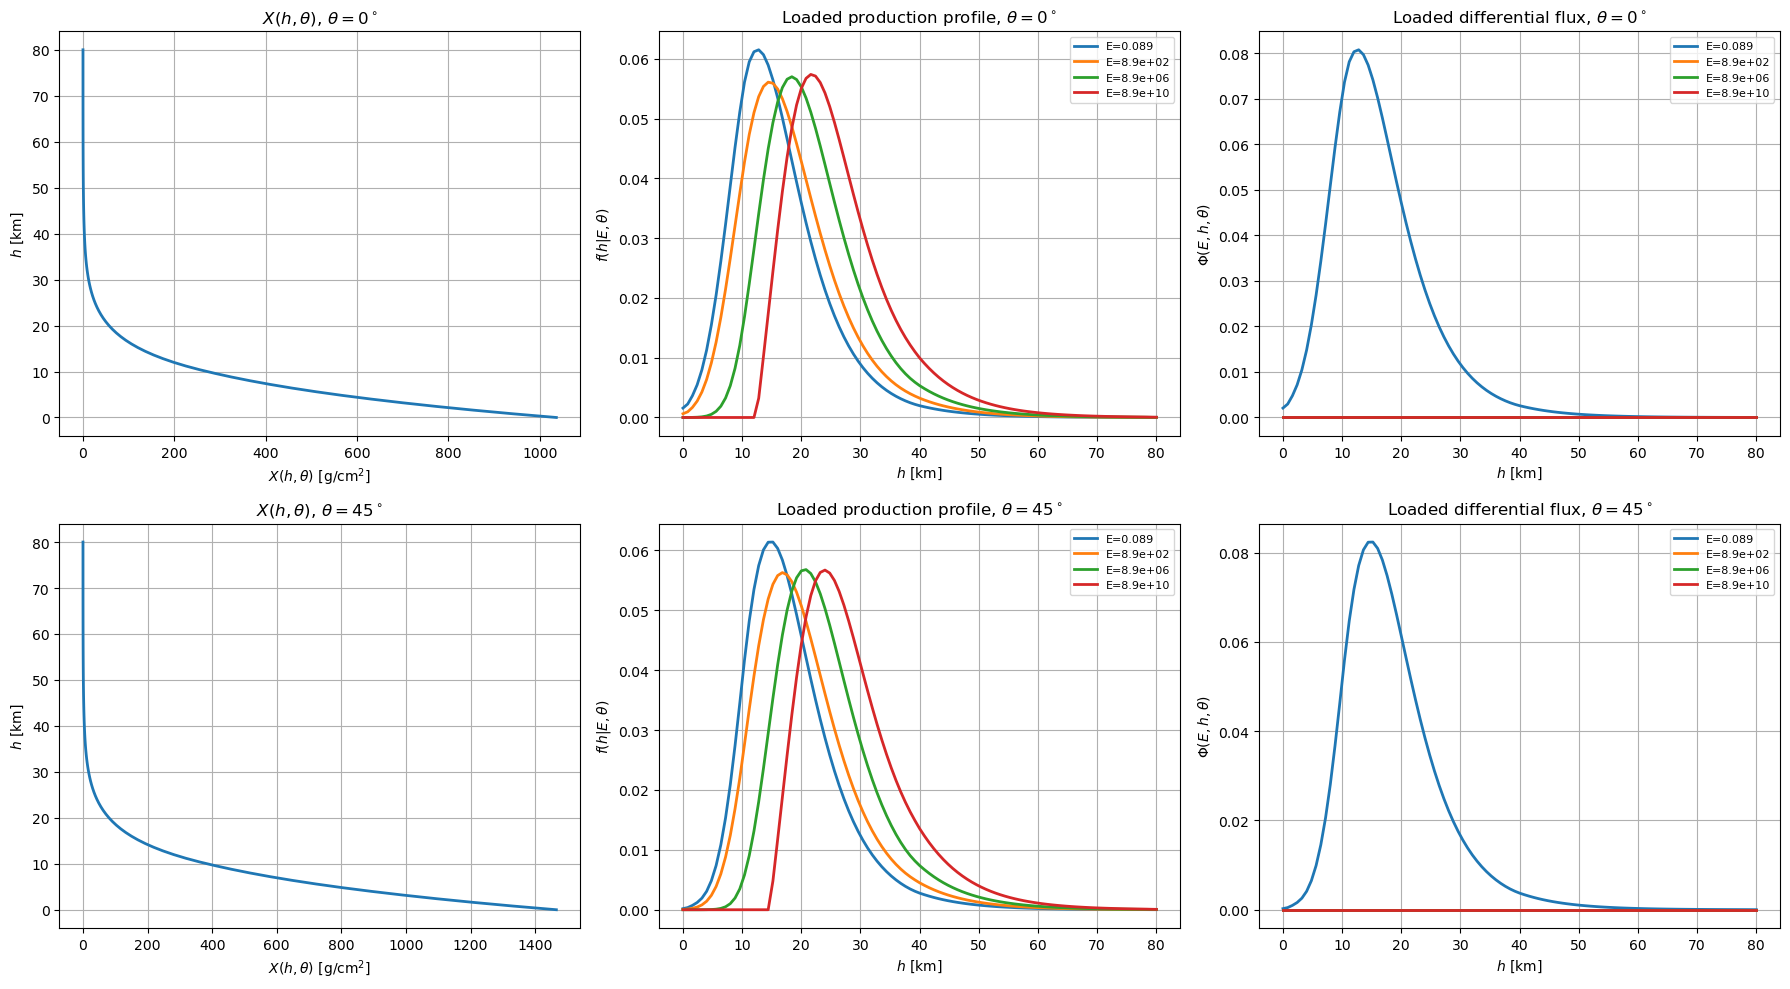

Saved plot: V:\output\test\mceq\test10_pipeline\test_pipeline_test0_figure_010.png


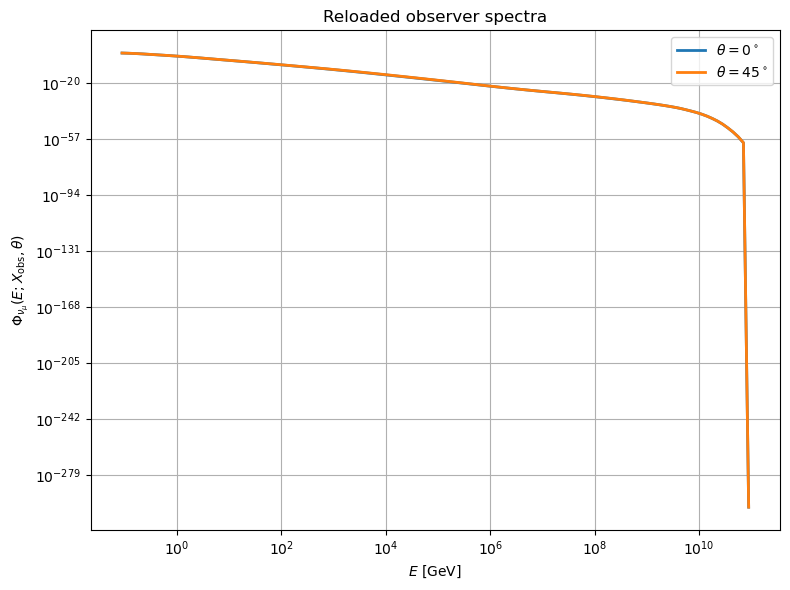


Saved files:
theta=0 deg -> V:\output\test\mceq\test10_pipeline\phi_E_theta_h_test0_numu_theta_0p000deg.pt
theta=45 deg -> V:\output\test\mceq\test10_pipeline\phi_E_theta_h_test0_numu_theta_45p000deg.pt

Pipeline finished.
------------------------------------------------------------------------------------------
PASSED: test_pipeline_test0


In [5]:
run_notebook_test(TEST_MODULE.test_pipeline_test0)
